In [7]:
# Why: Pandas for data handling; Seaborn/Matplotlib for pro charts; ₹ parsing for numerics.
!pip install seaborn matplotlib
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
sns.set_style("whitegrid")
print("✅ Ready!")


✅ Ready!


In [8]:
# Why: read_csv auto-detects headers; describe() reveals price distributions.
from google.colab import files
import io
uploaded = files.upload()  # Or drag-drop sales.csv
df = pd.read_csv(io.BytesIO(list(uploaded.values())[0]))
print("Shape:", df.shape)
print("\nColumns:", df.columns.tolist())
print("\nFirst rows:")
df.head(3)
print("\nStats:")
df.describe()


Saving sales.csv to sales (1).csv
Shape: (1465, 16)

Columns: ['product_id', 'product_name', 'category', 'discounted_price', 'actual_price', 'discount_percentage', 'rating', 'rating_count', 'about_product', 'user_id', 'user_name', 'review_id', 'review_title', 'review_content', 'img_link', 'product_link']

First rows:

Stats:


,product_id,product_name,category,discounted_price,actual_price,discount_percentage,rating,rating_count,about_product,user_id,user_name,review_id,review_title,review_content,img_link,product_link
count,1465,1465,1465,1465,1465,1465,1465,1463,1465,1465,1465,1465,1465,1465,1465,1465
unique,1351,1337,211,550,449,92,28,1143,1293,1194,1194,1194,1194,1212,1412,1465
top,B083342NKJ,"Fire-Boltt Ninja Call Pro Plus 1.83"" Smart Wat...",Computers&Accessories|Accessories&Peripherals|...,₹199,₹999,50%,4.1,"9,378",[CHARGE & SYNC FUNCTION]- This cable comes wit...,"AHIKJUDTVJ4T6DV6IUGFYZ5LXMPA,AE55KTFVNXYFD5FPY...","$@|\|TO$|-|,Sethu madhav,Akash Thakur,Burger P...","R3F4T5TRYPTMIG,R3DQIEC603E7AY,R1O4Z15FD40PV5,R...","Worked on iPhone 7 and didn’t work on XR,Good ...","I am not big on camera usage, personally. I wa...",https://m.media-amazon.com/images/I/413sCRKobN...,https://www.amazon.in/Borosil-Jumbo-1000-Watt-...
freq,3,5,233,53,120,56,244,9,6,10,10,10,10,8,3,1


In [9]:
# Why: Extract numbers from ₹ strings (pd.to_numeric); split category pipe; handle quotes.
# Creates 'revenue_proxy' = actual_price (sales insight); top-level category.
df['discounted_price'] = df['discounted_price'].str.replace('₹', '').str.replace(',', '').astype(float)
df['actual_price'] = df['actual_price'].str.replace('₹', '').str.replace(',', '').astype(float)
df['discount_percentage'] = df['discount_percentage'].str.replace('%', '').astype(float)
df['rating_count'] = pd.to_numeric(df['rating_count'], errors='coerce')

# Category cleanup
df['main_category'] = df['category'].str.split('|').str[0]
df['revenue_proxy'] = df['actual_price']  # MRSP as sales volume indicator

# Top categories
print("Top categories:", df['main_category'].value_counts().head())
df.head()


Top categories: main_category
Electronics              526
Computers&Accessories    453
Home&Kitchen             448
OfficeProducts            31
MusicalInstruments         2
Name: count, dtype: int64


,product_id,product_name,category,discounted_price,actual_price,discount_percentage,rating,rating_count,about_product,user_id,user_name,review_id,review_title,review_content,img_link,product_link,main_category,revenue_proxy
0,B07JW9H4J1,Wayona Nylon Braided USB to Lightning Fast Cha...,Computers&Accessories|Accessories&Peripherals|...,399.0,1099.0,64.0,4.2,NaN,High Compatibility : Compatible With iPhone 12...,"AG3D6O4STAQKAY2UVGEUV46KN35Q,AHMY5CWJMMK5BJRBB...","Manav,Adarsh gupta,Sundeep,S.Sayeed Ahmed,jasp...","R3HXWT0LRP0NMF,R2AJM3LFTLZHFO,R6AQJGUP6P86,R1K...","Satisfied,Charging is really fast,Value for mo...",Looks durable Charging is fine tooNo complains...,https://m.media-amazon.com/images/W/WEBP_40237...,https://www.amazon.in/Wayona-Braided-WN3LG1-Sy...,Computers&Accessories,1099.0
1,B098NS6PVG,Ambrane Unbreakable 60W / 3A Fast Charging 1.5...,Computers&Accessories|Accessories&Peripherals|...,199.0,349.0,43.0,4.0,NaN,"Compatible with all Type C enabled devices, be...","AECPFYFQVRUWC3KGNLJIOREFP5LQ,AGYYVPDD7YG7FYNBX...","ArdKn,Nirbhay kumar,Sagar Viswanathan,Asp,Plac...","RGIQEG07R9HS2,R1SMWZQ86XIN8U,R2J3Y1WL29GWDE,RY...","A Good Braided Cable for Your Type C Device,Go...",I ordered this cable to connect my phone to An...,https://m.media-amazon.com/images/W/WEBP_40237...,https://www.amazon.in/Ambrane-Unbreakable-Char...,Computers&Accessories,349.0
2,B096MSW6CT,Sounce Fast Phone Charging Cable & Data Sync U...,Computers&Accessories|Accessories&Peripherals|...,199.0,1899.0,90.0,3.9,NaN,【 Fast Charger& Data Sync】-With built-in safet...,"AGU3BBQ2V2DDAMOAKGFAWDDQ6QHA,AESFLDV2PT363T2AQ...","Kunal,Himanshu,viswanath,sai niharka,saqib mal...","R3J3EQQ9TZI5ZJ,R3E7WBGK7ID0KV,RWU79XKQ6I1QF,R2...","Good speed for earlier versions,Good Product,W...","Not quite durable and sturdy,https://m.media-a...",https://m.media-amazon.com/images/W/WEBP_40237...,https://www.amazon.in/Sounce-iPhone-Charging-C...,Computers&Accessories,1899.0
3,B08HDJ86NZ,boAt Deuce USB 300 2 in 1 Type-C & Micro USB S...,Computers&Accessories|Accessories&Peripherals|...,329.0,699.0,53.0,4.2,NaN,The boAt Deuce USB 300 2 in 1 cable is compati...,"AEWAZDZZJLQUYVOVGBEUKSLXHQ5A,AG5HTSFRRE6NL3M5S...","Omkar dhale,JD,HEMALATHA,Ajwadh a.,amar singh ...","R3EEUZKKK9J36I,R3HJVYCLYOY554,REDECAZ7AMPQC,R1...","Good product,Good one,Nice,Really nice product...","Good product,long wire,Charges good,Nice,I bou...",https://m.media-amazon.com/images/I/41V5FtEWPk...,https://www.amazon.in/Deuce-300-Resistant-Tang...,Computers&Accessories,699.0
4,B08CF3B7N1,Portronics Konnect L 1.2M Fast Charging 3A 8 P...,Computers&Accessories|Accessories&Peripherals|...,154.0,399.0,61.0,4.2,NaN,[CHARGE & SYNC FUNCTION]- This cable comes wit...,"AE3Q6KSUK5P75D5HFYHCRAOLODSA,AFUGIFH5ZAFXRDSZH...","rahuls6099,Swasat Borah,Ajay Wadke,Pranali,RVK...","R1BP4L2HH9TFUP,R16PVJEXKV6QZS,R2UPDB81N66T4P,R...","As good as original,Decent,Good one for second...","Bought this instead of original apple, does th...",https://m.media-amazon.com/images/W/WEBP_40237...,https://www.amazon.in/Portronics-Konnect-POR-1...,Computers&Accessories,399.0


/tmp/ipykernel_4022/1045163619.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(y=top_cats.index, x=top_cats.values, palette='viridis')


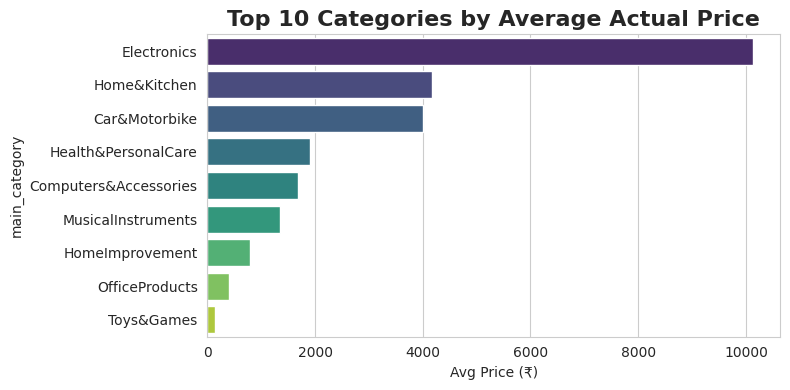

<Figure size 640x480 with 0 Axes>

In [12]:
# Why: groupby aggregates; barplot compares categories (business: which segments high-value?).
plt.figure(figsize=(8, 4))
top_cats = df.groupby('main_category')['actual_price'].mean().sort_values(ascending=False).head(10)
sns.barplot(y=top_cats.index, x=top_cats.values, palette='viridis')
plt.title('Top 10 Categories by Average Actual Price', fontweight='bold', fontsize=16)
plt.xlabel('Avg Price (₹)')
plt.tight_layout()
plt.show()
plt.savefig('top_categories_price.png', dpi=300)


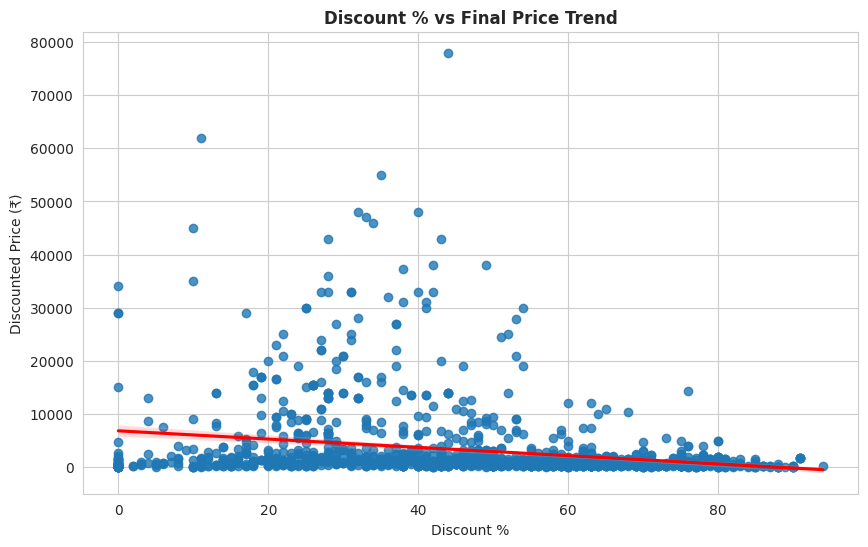

<Figure size 640x480 with 0 Axes>

In [13]:
# Why: Scatter with trendline (sns.regplot) shows discount impact on price—key sales insight.
plt.figure(figsize=(10, 6))
sns.regplot(data=df, x='discount_percentage', y='discounted_price', line_kws={'color':'red'})
plt.title('Discount % vs Final Price Trend', fontweight='bold')
plt.xlabel('Discount %')
plt.ylabel('Discounted Price (₹)')
plt.show()
plt.savefig('discount_trend.png', dpi=300)


/tmp/ipykernel_4022/630878827.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(y=top_rated.index, x=top_rated.values, palette='coolwarm')


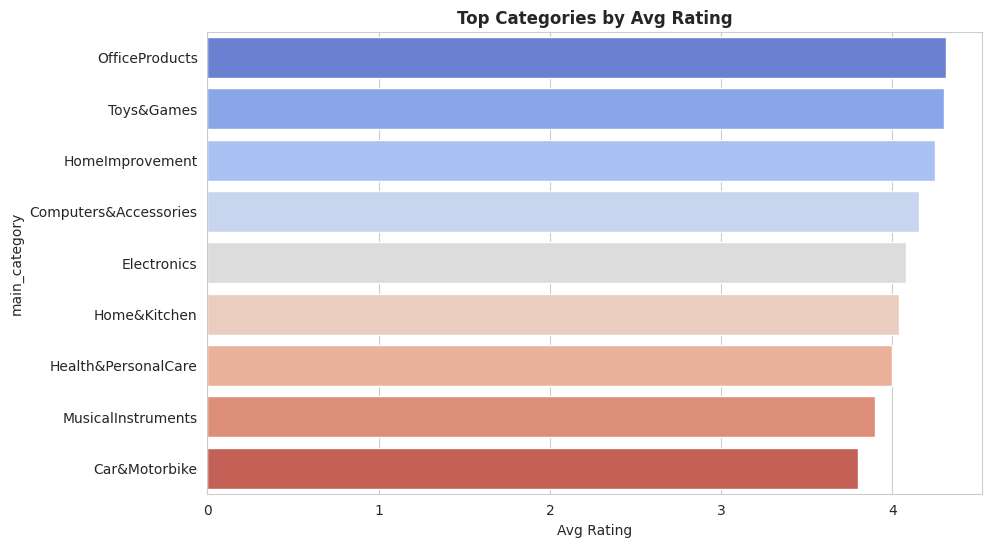

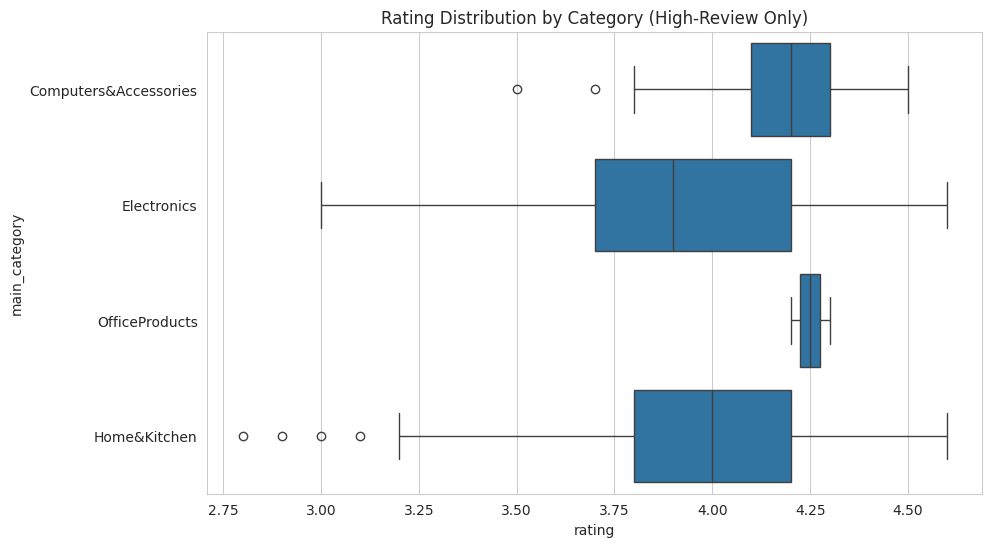

<Figure size 640x480 with 0 Axes>

In [16]:
# No dates → Rating by Category (proxy for sales quality).
# Convert 'rating' to numeric type, coercing errors to NaN
df['rating'] = pd.to_numeric(df['rating'], errors='coerce')

plt.figure(figsize=(10, 6))
top_rated = df.groupby('main_category')['rating'].mean().sort_values(ascending=False).head(10)
sns.barplot(y=top_rated.index, x=top_rated.values, palette='coolwarm')
plt.title('Top Categories by Avg Rating', fontweight='bold')
plt.xlabel('Avg Rating')
plt.show()

# Boxplot: Rating distribution
plt.figure(figsize=(10, 6))
sns.boxplot(data=df[df['rating_count']>100], x='rating', y='main_category')
plt.title('Rating Distribution by Category (High-Review Only)')
plt.show()
plt.savefig('ratings_analysis.png', dpi=300)

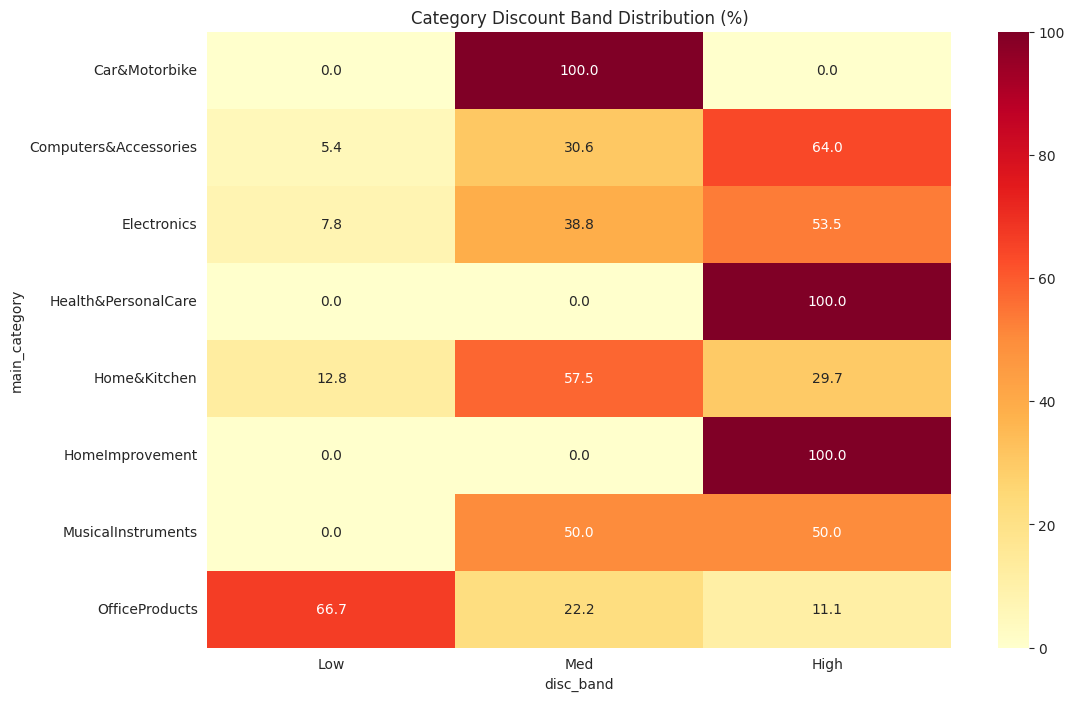

Total Potential Savings Across Dataset: ₹3,398,331


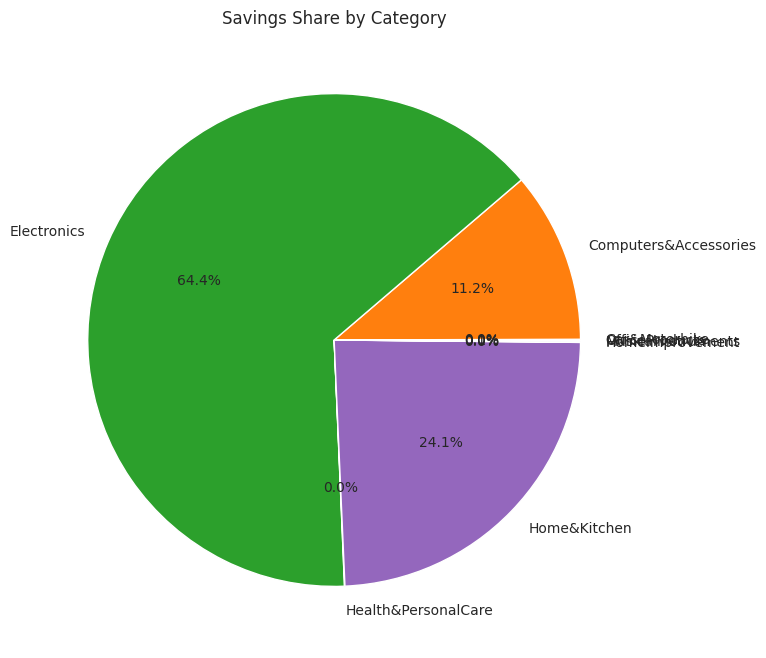

<Figure size 640x480 with 0 Axes>

In [17]:
# Why: crosstab counts; heatmap shows category-rating matrix; pie for discount shares.
# Industry: Identifies high-discount low-rating traps.

# Discount bands
df['disc_band'] = pd.cut(df['discount_percentage'], bins=[0,20,50,100], labels=['Low','Med','High'])

pivot = pd.crosstab(df['main_category'], df['disc_band'], normalize='index') * 100
plt.figure(figsize=(12, 8))
sns.heatmap(pivot.head(10), annot=True, cmap='YlOrRd', fmt='.1f')
plt.title('Category Discount Band Distribution (%)')
plt.show()

# Pie: Total discount savings
total_savings = (df['actual_price'] - df['discounted_price']).sum()
print(f"Total Potential Savings Across Dataset: ₹{total_savings:,.0f}")

plt.figure(figsize=(8,8))
cat_savings = df.groupby('main_category')['actual_price'].sum() - df.groupby('main_category')['discounted_price'].sum()
plt.pie(cat_savings.head(8).values, labels=cat_savings.head(8).index, autopct='%1.1f%%')
plt.title('Savings Share by Category')
plt.show()
plt.savefig('savings_heatmap.png', dpi=300)


In [18]:
# Why: Processed CSV + PNGs for reports/portfolio.
df.to_csv('processed_sales_analysis.csv', index=False)
files.download('processed_sales_analysis.csv')

insights = {
    'Cheapest Category': df.groupby('main_category')['discounted_price'].mean().idxmin(),
    'Highest Avg Discount': df.groupby('main_category')['discount_percentage'].mean().max(),
    'Best Rated Category': df.groupby('main_category')['rating'].mean().idxmax()
}
print("🚀 Key Insights:", insights)
print("📊 Files ready for download!")


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

🚀 Key Insights: {'Cheapest Category': 'Toys&Games', 'Highest Avg Discount': 57.5, 'Best Rated Category': 'OfficeProducts'}
📊 Files ready for download!
